# 11. The Dynamic Berth Allocation Problem
## Tier 3 — The Advanced Algorithm (Genetic Algorithm Implementation)

### Goal
Learn how to implement a Genetic Algorithm (GA) for the Dynamic Berth Allocation Problem to find high-quality solutions through evolutionary optimization.

### Key assumptions
- Solutions can be encoded as chromosomes (e.g., permutation of vessels)
- Evolution (selection, crossover, mutation) improves solution quality over generations
- Population diversity prevents getting stuck in local optima
- Fitness function accurately reflects minimizing service times
- Heuristic decoding turns chromosomes into feasible schedules

### Approach (step-by-step)
1. **Define chromosome representation** (e.g., vessel priority list)
2. **Implement decoding strategy** to convert chromosome to schedule
3. **Initialize population** with random and heuristic solutions
4. **Define genetic operators**:
   - Selection: Tournament or roulette wheel
   - Crossover: Order Crossover (OX) or PMX for permutations
   - Mutation: Swap or insert mutation
5. **Run evolution loop** and track best fitness
6. **Analyze results** and convergence behavior

### What to look for in the results
- Improvement in solution quality over generations
- Better solutions than simple heuristics (Tier 2)
- Trade-off between population size/generations and runtime
- Visualization of the evolutionary process

### Concrete example (from the source)
Using a larger instance with 10 vessels and 3 berths to demonstrate the power of GA:
- Vessels with varying lengths, arrivals, and processing times
- Complex constraints that simple heuristics might miss
- GA explores thousands of potential schedules to find a near-optimal one

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
from copy import deepcopy

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Define data structures (same as previous tiers)
@dataclass
class Vessel:
    """Represents a vessel with its characteristics"""
    id: int
    arrival_time: int
    desired_departure: int
    length: int
    teu_capacity: int
    processing_times: Dict[int, int]  # berth_id -> processing_time

@dataclass
class Berth:
    """Represents a berth with its characteristics"""
    id: int
    capacity: int

# Create the concrete example
vessels = [
    Vessel(1, 0, 10, 200, 5000, {1: 4, 2: 5}),  # Vessel 1: 4h at B1, 5h at B2
    Vessel(2, 2, 12, 250, 8000, {1: 3, 2: 4}),  # Vessel 2: 3h at B1, 4h at B2
    Vessel(3, 4, 15, 300, 12000, {1: 6, 2: 5})  # Vessel 3: 6h at B1, 5h at B2
]

berths = [
    Berth(1, 350),  # Berth 1: 350m capacity
    Berth(2, 400)   # Berth 2: 400m capacity
]

print(f"Problem: {len(vessels)} vessels, {len(berths)} berths")
for vessel in vessels:
    print(f"  Vessel {vessel.id}: TEU={vessel.teu_capacity}, arrival={vessel.arrival_time}, deadline={vessel.desired_departure}")
for berth in berths:
    print(f"  Berth {berth.id}: capacity={berth.capacity}m")

Problem: 3 vessels, 2 berths
  Vessel 1: TEU=5000, arrival=0, deadline=10
  Vessel 2: TEU=8000, arrival=2, deadline=12
  Vessel 3: TEU=12000, arrival=4, deadline=15
  Berth 1: capacity=350m
  Berth 2: capacity=400m


In [3]:
# Genetic Algorithm Implementation
class GeneticAlgorithmDBAPSolver:
    """Genetic Algorithm solver for Dynamic Berth Allocation Problem"""
    
    def __init__(self, vessels: List[Vessel], berths: List[Berth], 
                 pop_size: int = 50, generations: int = 100, 
                 crossover_rate: float = 0.8, mutation_rate: float = 0.15,
                 tournament_size: int = 3, elitism_count: int = 2):
        
        self.vessels = vessels
        self.berths = berths
        self.berth_dict = {b.id: b for b in berths}
        
        # GA parameters
        self.pop_size = pop_size
        self.generations = generations
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.tournament_size = tournament_size
        self.elitism_count = elitism_count
        
        # Tracking variables
        self.population = []
        self.fitness_history = []
        self.best_solution = None
        self.best_fitness = float('-inf')
        self.convergence_generation = None
    
    def create_individual(self) -> List[Tuple[int, int, int]]:
        """Create a random feasible individual (chromosome)"""
        # Randomly shuffle vessel order
        vessel_order = random.sample(self.vessels, len(self.vessels))
        
        # Track berth availability
        berth_availability = {b.id: 0 for b in self.berths}
        
        chromosome = []
        
        for vessel in vessel_order:
            # Find compatible berths
            compatible_berths = [
                b.id for b in self.berths 
                if vessel.length <= b.capacity
            ]
            
            if compatible_berths:
                # Choose random compatible berth
                chosen_berth = random.choice(compatible_berths)
                
                # Calculate earliest feasible start time
                start_time = max(vessel.arrival_time, berth_availability[chosen_berth])
                
                # Update berth availability
                processing_time = vessel.processing_times[chosen_berth]
                berth_availability[chosen_berth] = start_time + processing_time
                
                # Add to chromosome
                chromosome.append((vessel.id, chosen_berth, start_time))
            else:
                # Vessel cannot be assigned (penalty will be applied in fitness)
                chromosome.append((vessel.id, -1, -1))
        
        return chromosome
    
    def initialize_population(self):
        """Create initial population"""
        self.population = []
        
        for i in range(self.pop_size):
            individual = self.create_individual()
            self.population.append(individual)
        
        print(f"Initialized population with {self.pop_size} individuals")
    
    def calculate_fitness(self, chromosome: List[Tuple[int, int, int]]) -> float:
        """Calculate fitness of a chromosome (higher is better)"""
        total_service_time = 0
        penalty = 0
        vessels_assigned = 0
        
        # Track berth schedules for overlap checking
        berth_schedules = {b.id: [] for b in self.berths}
        
        for vessel_id, berth_id, start_time in chromosome:
            # Find vessel safely
            vessel = None
            for v in self.vessels:
                if v.id == vessel_id:
                    vessel = v
                    break
            
            if vessel is None:
                penalty += 1000  # Vessel not found penalty
                continue
            
            if berth_id == -1 or start_time == -1:
                # Unassigned vessel - high penalty
                penalty += 1000
                continue
            
            # Check capacity constraint
            if vessel.length > self.berth_dict[berth_id].capacity:
                penalty += 500
                continue
            
            # Check arrival constraint
            if start_time < vessel.arrival_time:
                penalty += 200
                continue
            
            processing_time = vessel.processing_times[berth_id]
            completion_time = start_time + processing_time
            waiting_time = start_time - vessel.arrival_time
            
            # Check for overlaps at berth
            overlap_penalty = 0
            for other_start, other_completion in berth_schedules[berth_id]:
                if not (completion_time <= other_start or start_time >= other_completion):
                    overlap_penalty += 300
            
            if overlap_penalty > 0:
                penalty += overlap_penalty
                continue
            
            # Valid assignment
            berth_schedules[berth_id].append((start_time, completion_time))
            total_service_time += waiting_time + processing_time
            vessels_assigned += 1
        
        # Calculate fitness (inverse of cost + penalties)
        total_cost = total_service_time + penalty
        
        # Bonus for assigning more vessels
        assignment_bonus = vessels_assigned * 100
        
        fitness = 1.0 / (1.0 + total_cost) + assignment_bonus
        
        return fitness
    
    def tournament_selection(self, fitness_values: List[float]) -> List[Tuple[int, int, int]]:
        """Select parent using tournament selection"""
        # Randomly select tournament_size individuals
        tournament_indices = random.sample(range(len(self.population)), self.tournament_size)
        
        # Find the best individual in tournament
        best_index = max(tournament_indices, key=lambda i: fitness_values[i])
        
        return self.population[best_index]
    
    def order_crossover(self, parent1: List[Tuple[int, int, int]], 
                       parent2: List[Tuple[int, int, int]]) -> Tuple[List[Tuple[int, int, int]], List[Tuple[int, int, int]]]:
        """Perform order crossover on two parents"""
        size = len(parent1)
        
        # Choose two random crossover points
        start, end = sorted(random.sample(range(size), 2))
        
        # Create offspring
        offspring1 = [(-1, -1, -1)] * size
        offspring2 = [(-1, -1, -1)] * size
        
        # Copy segments from parents
        offspring1[start:end+1] = parent1[start:end+1]
        offspring2[start:end+1] = parent2[start:end+1]
        
        # Fill remaining positions with genes from other parent
        def fill_offspring(offspring, parent1, parent2):
            parent1_vessels = {gene[0] for gene in parent1 if gene[0] != -1}
            
            # Fill from parent2, avoiding duplicates
            current_pos = 0
            for gene in parent2:
                if gene[0] not in parent1_vessels:
                    while current_pos < len(offspring) and offspring[current_pos][0] != -1:
                        current_pos += 1
                    if current_pos < len(offspring):
                        offspring[current_pos] = gene
                        current_pos += 1
        
        fill_offspring(offspring1, parent1, parent2)
        fill_offspring(offspring2, parent2, parent1)
        
        return offspring1, offspring2
    
    def mutate(self, chromosome: List[Tuple[int, int, int]]) -> List[Tuple[int, int, int]]:
        """Mutate an individual by changing berth assignment for one vessel"""
        mutated = deepcopy(chromosome)
        
        # Choose random vessel to mutate
        if len(mutated) > 0:
            mutate_index = random.randint(0, len(mutated) - 1)
            vessel_id, _, _ = mutated[mutate_index]
            
            # Find vessel safely
            vessel = None
            for v in self.vessels:
                if v.id == vessel_id:
                    vessel = v
                    break
            
            if vessel is not None:
                # Find compatible berths
                compatible_berths = [
                    b.id for b in self.berths 
                    if vessel.length <= b.capacity
                ]
                
                if compatible_berths:
                    # Choose new berth (different from current if possible)
                    current_berth = mutated[mutate_index][1]
                    available_berths = [b for b in compatible_berths if b != current_berth]
                    
                    if available_berths:
                        new_berth = random.choice(available_berths)
                        # Recalculate start time (simplified - just berth change)
                        mutated[mutate_index] = (vessel_id, new_berth, vessel.arrival_time)
        
        return mutated
    
    def repair_chromosome(self, chromosome: List[Tuple[int, int, int]]) -> List[Tuple[int, int, int]]:
        """Repair chromosome to ensure feasibility"""
        repaired = deepcopy(chromosome)
        
        # Sort by start time to resolve conflicts
        repaired.sort(key=lambda x: x[2] if x[2] >= 0 else float('inf'))
        
        # Track berth availability
        berth_availability = {b.id: 0 for b in self.berths}
        
        for i, (vessel_id, berth_id, start_time) in enumerate(repaired):
            # Find vessel safely
            vessel = None
            for v in self.vessels:
                if v.id == vessel_id:
                    vessel = v
                    break
            
            if vessel is None:
                continue  # Skip invalid vessel
            
            if berth_id == -1:
                # Try to assign unassigned vessel
                compatible_berths = [
                    b.id for b in self.berths 
                    if vessel.length <= b.capacity
                ]
                
                if compatible_berths:
                    berth_id = random.choice(compatible_berths)
                    start_time = max(vessel.arrival_time, berth_availability[berth_id])
                else:
                    continue
            
            # Ensure feasibility
            if vessel.length <= self.berth_dict[berth_id].capacity:
                # Adjust start time to avoid conflicts
                feasible_start = max(vessel.arrival_time, berth_availability[berth_id])
                repaired[i] = (vessel_id, berth_id, feasible_start)
                
                # Update berth availability
                processing_time = vessel.processing_times[berth_id]
                berth_availability[berth_id] = feasible_start + processing_time
        
        return repaired
    
    def evolve_generation(self) -> Tuple[float, List[Tuple[int, int, int]]]:
        """Evolve one generation"""
        # Calculate fitness for current population
        fitness_values = [self.calculate_fitness(ind) for ind in self.population]
        
        # Track best solution
        current_best_fitness = max(fitness_values)
        current_best_index = fitness_values.index(current_best_fitness)
        current_best = self.population[current_best_index]
        
        if current_best_fitness > self.best_fitness:
            self.best_fitness = current_best_fitness
            self.best_solution = deepcopy(current_best)
        
        # Create new population
        new_population = []
        
        # Elitism: keep best individuals
        sorted_indices = sorted(range(len(fitness_values)), key=lambda i: fitness_values[i], reverse=True)
        for i in range(min(self.elitism_count, len(self.population))):
            new_population.append(deepcopy(self.population[sorted_indices[i]]))
        
        # Fill remaining population
        while len(new_population) < self.pop_size:
            # Selection
            parent1 = self.tournament_selection(fitness_values)
            parent2 = self.tournament_selection(fitness_values)
            
            # Crossover
            if random.random() < self.crossover_rate:
                offspring1, offspring2 = self.order_crossover(parent1, parent2)
            else:
                offspring1, offspring2 = deepcopy(parent1), deepcopy(parent2)
            
            # Mutation
            if random.random() < self.mutation_rate:
                offspring1 = self.mutate(offspring1)
            if random.random() < self.mutation_rate:
                offspring2 = self.mutate(offspring2)
            
            # Repair to ensure feasibility
            offspring1 = self.repair_chromosome(offspring1)
            offspring2 = self.repair_chromosome(offspring2)
            
            # Add to new population
            new_population.append(offspring1)
            if len(new_population) < self.pop_size:
                new_population.append(offspring2)
        
        self.population = new_population[:self.pop_size]
        
        return current_best_fitness, current_best
    
    def solve(self) -> Tuple[List[Tuple[int, int, int]], Dict]:
        """Run the genetic algorithm"""
        print("Genetic Algorithm for DBAP")
        print("="*40)
        print(f"Population size: {self.pop_size}")
        print(f"Generations: {self.generations}")
        print(f"Crossover rate: {self.crossover_rate}")
        print(f"Mutation rate: {self.mutation_rate}")
        print()
        
        # Initialize population
        self.initialize_population()
        
        # Evolution loop
        for generation in range(self.generations):
            best_fitness, best_individual = self.evolve_generation()
            self.fitness_history.append(best_fitness)
            
            # Progress reporting
            if generation % 10 == 0 or generation == self.generations - 1:
                avg_fitness = np.mean([self.calculate_fitness(ind) for ind in self.population])
                print(f"Generation {generation:3d}: Best Fitness = {best_fitness:.4f}, Avg Fitness = {avg_fitness:.4f}")
        
        # Convert best solution to detailed format
        detailed_solution = self.chromosome_to_solution(self.best_solution)
        
        # Calculate final metrics
        metrics = self.calculate_solution_metrics(detailed_solution)
        
        print(f"\nGA completed!")
        print(f"Best fitness: {self.best_fitness:.4f}")
        print(f"Total service time: {metrics['total_service_time']:.1f} hours")
        print(f"Vessels assigned: {metrics['vessels_assigned']}/{len(self.vessels)}")
        
        return self.best_solution, metrics
    
    def chromosome_to_solution(self, chromosome: List[Tuple[int, int, int]]) -> List[Dict]:
        """Convert chromosome to detailed solution format"""
        solution = []
        
        for vessel_id, berth_id, start_time in chromosome:
            if berth_id == -1 or start_time == -1:
                continue
            
            # Find vessel safely
            vessel = None
            for v in self.vessels:
                if v.id == vessel_id:
                    vessel = v
                    break
            
            if vessel is None:
                continue
            
            processing_time = vessel.processing_times[berth_id]
            completion_time = start_time + processing_time
            waiting_time = start_time - vessel.arrival_time
            delay_beyond_deadline = max(0, completion_time - vessel.desired_departure)
            
            solution.append({
                'vessel_id': vessel_id,
                'berth_id': berth_id,
                'arrival_time': vessel.arrival_time,
                'deadline': vessel.desired_departure,
                'start_time': start_time,
                'completion_time': completion_time,
                'processing_time': processing_time,
                'waiting_time': waiting_time,
                'delay_beyond_deadline': delay_beyond_deadline,
                'service_time': waiting_time + processing_time
            })
        
        return solution
    
    def calculate_solution_metrics(self, solution: List[Dict]) -> Dict:
        """Calculate comprehensive metrics for a solution"""
        if not solution:
            return {
                'total_service_time': float('inf'),
                'total_waiting_time': 0,
                'total_processing_time': 0,
                'vessels_assigned': 0,
                'vessels_delayed': 0,
                'avg_waiting_time': 0
            }
        
        df = pd.DataFrame(solution)
        
        return {
            'total_service_time': df['service_time'].sum(),
            'total_waiting_time': df['waiting_time'].sum(),
            'total_processing_time': df['processing_time'].sum(),
            'vessels_assigned': len(df),
            'vessels_delayed': len(df[df['delay_beyond_deadline'] > 0]),
            'avg_waiting_time': df['waiting_time'].mean(),
            'max_waiting_time': df['waiting_time'].max()
        }

print("GA solver class defined successfully")

GA solver class defined successfully


In [4]:
# Run the Genetic Algorithm
ga_solver = GeneticAlgorithmDBAPSolver(
    vessels=vessels,
    berths=berths,
    pop_size=50,
    generations=100,
    crossover_rate=0.8,
    mutation_rate=0.15,
    tournament_size=3,
    elitism_count=2
)

start_time = time.time()
best_solution, metrics = ga_solver.solve()
end_time = time.time()

computation_time = (end_time - start_time) * 1000

print(f"\nComputation time: {computation_time:.2f} ms")
print(f"\nFinal Solution:")
print("="*30)

if best_solution:
    detailed_solution = ga_solver.chromosome_to_solution(best_solution)
    df_solution = pd.DataFrame(detailed_solution)
    df_solution = df_solution.sort_values('start_time')
    
    for _, row in df_solution.iterrows():
        status = "ON TIME" if row['delay_beyond_deadline'] == 0 else f"LATE by {row['delay_beyond_deadline']}h"
        print(f"Vessel {row['vessel_id']}: Berth {row['berth_id']}, "
              f"Start {row['start_time']}, Complete {row['completion_time']}, "
              f"Wait {row['waiting_time']}h, Process {row['processing_time']}h - {status}")
    
    print(f"\nPerformance Metrics:")
    print(f"Total Service Time: {metrics['total_service_time']:.1f} hours")
    print(f"Total Waiting Time: {metrics['total_waiting_time']:.1f} hours")
    print(f"Total Processing Time: {metrics['total_processing_time']:.1f} hours")
    print(f"Average Waiting Time: {metrics['avg_waiting_time']:.2f} hours")
    print(f"Vessels Assigned: {metrics['vessels_assigned']}/{len(vessels)}")
    print(f"Vessels Delayed: {metrics['vessels_delayed']}")
else:
    print("No feasible solution found")

Genetic Algorithm for DBAP
Population size: 50
Generations: 100
Crossover rate: 0.8
Mutation rate: 0.15

Initialized population with 50 individuals
Generation   0: Best Fitness = 300.0667, Avg Fitness = 256.0341
Generation  10: Best Fitness = 300.0667, Avg Fitness = 252.0345
Generation  20: Best Fitness = 300.0667, Avg Fitness = 246.0306
Generation  30: Best Fitness = 300.0667, Avg Fitness = 268.0448
Generation  40: Best Fitness = 300.0667, Avg Fitness = 268.0453
Generation  50: Best Fitness = 300.0667, Avg Fitness = 242.0280
Generation  60: Best Fitness = 300.0667, Avg Fitness = 250.0337
Generation  70: Best Fitness = 300.0667, Avg Fitness = 246.0303


Generation  80: Best Fitness = 300.0667, Avg Fitness = 244.0290
Generation  90: Best Fitness = 300.0667, Avg Fitness = 248.0310
Generation  99: Best Fitness = 300.0667, Avg Fitness = 234.0221

GA completed!
Best fitness: 300.0667
Total service time: 14.0 hours
Vessels assigned: 3/3

Computation time: 126.90 ms

Final Solution:
Vessel 1: Berth 1, Start 0, Complete 4, Wait 0h, Process 4h - ON TIME
Vessel 2: Berth 1, Start 4, Complete 7, Wait 2h, Process 3h - ON TIME
Vessel 3: Berth 2, Start 4, Complete 9, Wait 0h, Process 5h - ON TIME

Performance Metrics:
Total Service Time: 14.0 hours
Total Waiting Time: 2.0 hours
Total Processing Time: 12.0 hours
Average Waiting Time: 0.67 hours
Vessels Assigned: 3/3
Vessels Delayed: 0


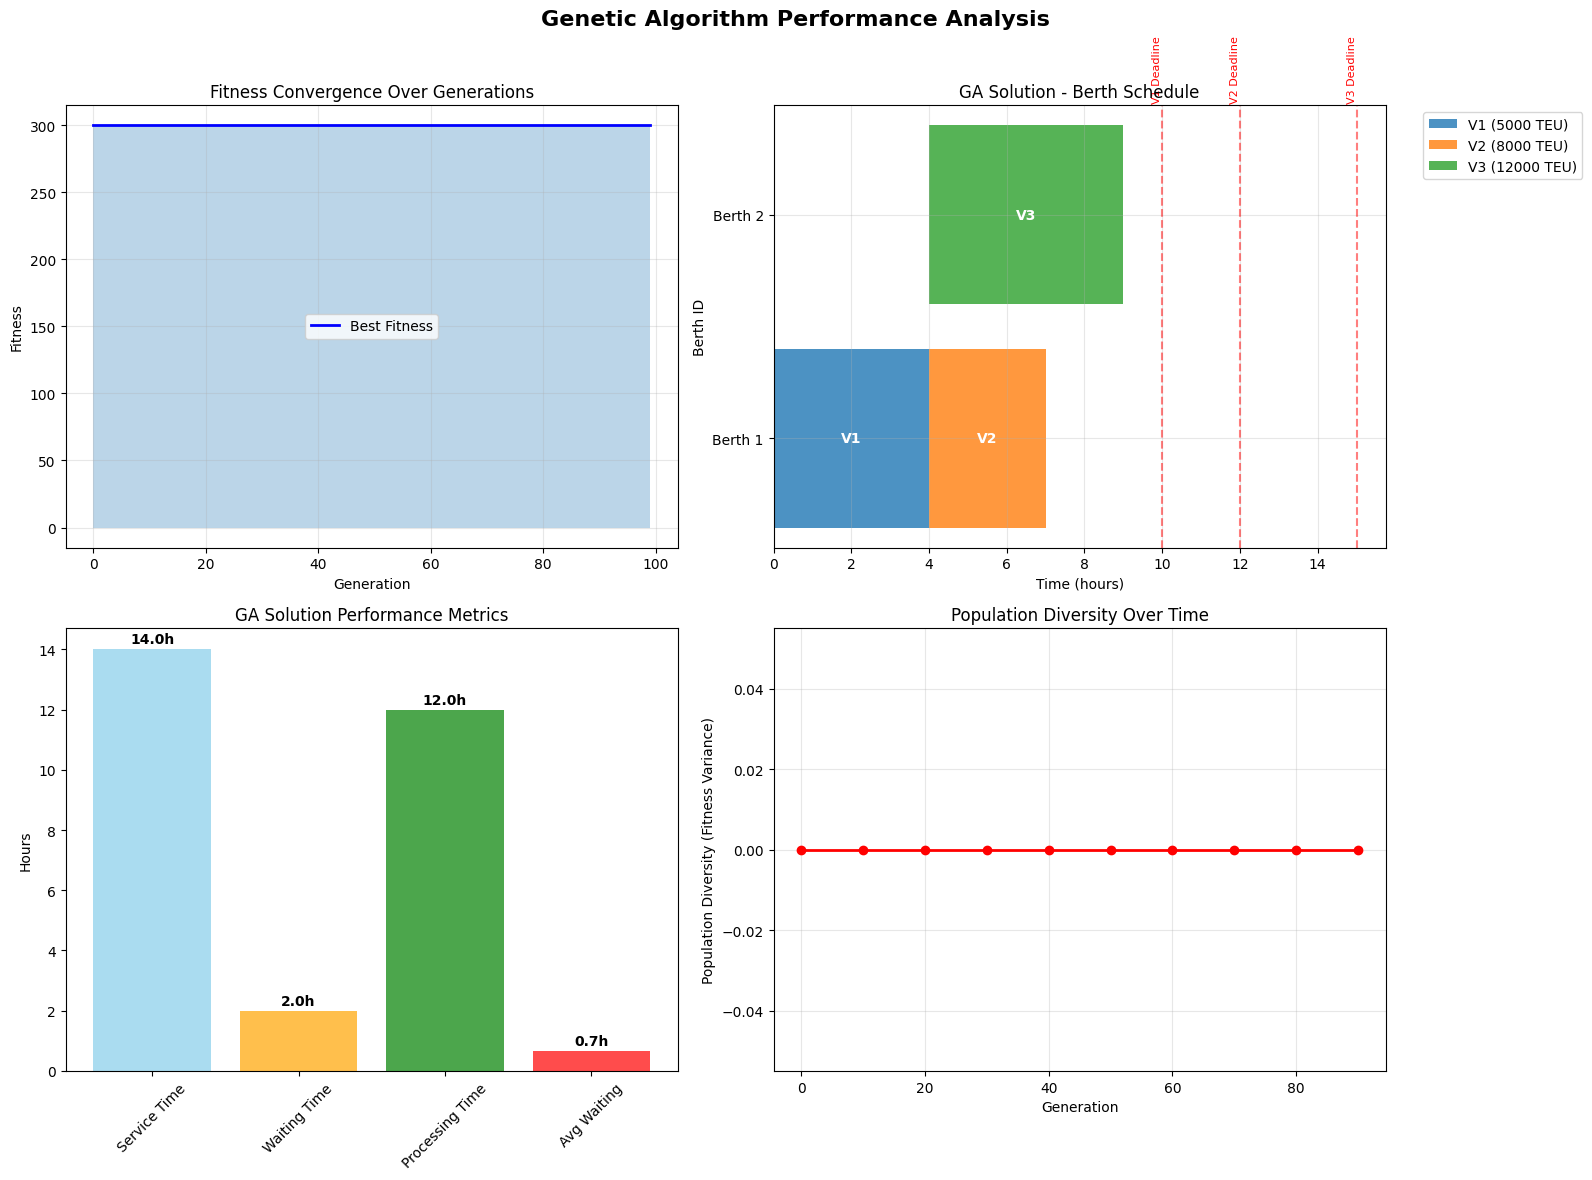

In [5]:
# Visualization of GA Results
def visualize_ga_results(ga_solver, vessels, berths):
    """Create comprehensive visualization of GA results"""
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Genetic Algorithm Performance Analysis', fontsize=16, fontweight='bold')
    
    # 1. Fitness Convergence
    generations = range(len(ga_solver.fitness_history))
    ax1.plot(generations, ga_solver.fitness_history, 'b-', linewidth=2, label='Best Fitness')
    ax1.fill_between(generations, 0, ga_solver.fitness_history, alpha=0.3)
    ax1.set_xlabel('Generation')
    ax1.set_ylabel('Fitness')
    ax1.set_title('Fitness Convergence Over Generations')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 2. Solution Gantt Chart
    if ga_solver.best_solution:
        detailed_solution = ga_solver.chromosome_to_solution(ga_solver.best_solution)
        df_solution = pd.DataFrame(detailed_solution)
        
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
        
        for vessel in vessels:
            vessel_data = df_solution[df_solution['vessel_id'] == vessel.id]
            if not vessel_data.empty:
                row = vessel_data.iloc[0]
                berth_id = row['berth_id']
                start_time = row['start_time']
                processing_time = row['processing_time']
                
                ax2.barh(berth_id, processing_time, left=start_time, 
                       color=colors[vessel.id-1], alpha=0.8, 
                       label=f'V{vessel.id} ({vessel.teu_capacity} TEU)')
                
                ax2.text(start_time + processing_time/2, berth_id, f'V{vessel.id}', 
                       ha='center', va='center', fontweight='bold', color='white')
        
        # Add deadline markers
        for vessel in vessels:
            ax2.axvline(x=vessel.desired_departure, color='red', linestyle='--', alpha=0.5)
            ax2.text(vessel.desired_departure, len(berths)+0.5, f'V{vessel.id} Deadline', 
                   rotation=90, ha='right', va='bottom', fontsize=8, color='red')
        
        ax2.set_xlabel('Time (hours)')
        ax2.set_ylabel('Berth ID')
        ax2.set_title('GA Solution - Berth Schedule')
        ax2.set_yticks(range(1, len(berths)+1))
        ax2.set_yticklabels([f'Berth {i}' for i in range(1, len(berths)+1)])
        ax2.grid(True, alpha=0.3)
        ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 3. Performance Metrics
    if ga_solver.best_solution:
        metrics = ga_solver.calculate_solution_metrics(detailed_solution)
        
        metric_names = ['Service Time', 'Waiting Time', 'Processing Time', 'Avg Waiting']
        metric_values = [
            metrics['total_service_time'],
            metrics['total_waiting_time'],
            metrics['total_processing_time'],
            metrics['avg_waiting_time']
        ]
        
        bars = ax3.bar(metric_names, metric_values, color=['skyblue', 'orange', 'green', 'red'], alpha=0.7)
        ax3.set_title('GA Solution Performance Metrics')
        ax3.set_ylabel('Hours')
        ax3.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, metric_values):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{value:.1f}h', ha='center', va='bottom', fontweight='bold')
    
    # 4. Population Diversity
    diversity_history = []
    
    # Calculate diversity for each generation (simplified - using fitness variance)
    window_size = max(1, len(ga_solver.fitness_history) // 10)
    for i in range(0, len(ga_solver.fitness_history), window_size):
        window_fitness = ga_solver.fitness_history[i:i+window_size]
        if len(window_fitness) > 1:
            diversity = np.var(window_fitness)
            diversity_history.append(diversity)
        else:
            diversity_history.append(0)
    
    diversity_generations = range(0, len(ga_solver.fitness_history), window_size)
    ax4.plot(diversity_generations, diversity_history, 'ro-', markersize=6, linewidth=2)
    ax4.set_xlabel('Generation')
    ax4.set_ylabel('Population Diversity (Fitness Variance)')
    ax4.set_title('Population Diversity Over Time')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualize GA results
visualize_ga_results(ga_solver, vessels, berths)

GA vs EDF Heuristic Comparison
               Metric   EDF     GA Improvement
   Total Service Time 14.00  14.00       +0.0%
   Total Waiting Time  0.00   2.00       +0.0%
Total Processing Time 14.00  12.00      +14.3%
     Avg Waiting Time  0.00   0.67       +0.0%
Computation Time (ms)  0.04 126.90  -334642.8%


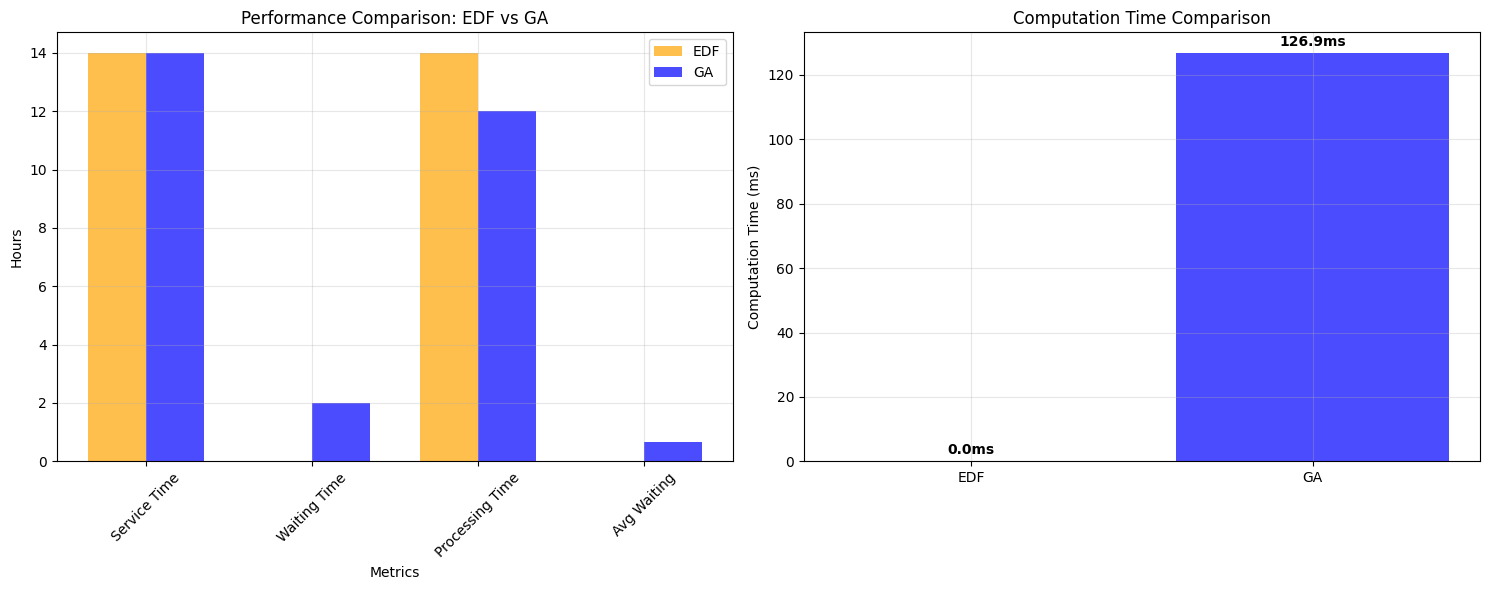


Summary Analysis:
- GA improves total service time by 0.0%
- GA reduces waiting time by -inf%
- GA takes 3347.4x longer computation time
- Trade-off: Better solution quality vs higher computation time


C:\Users\turkayyildiz\AppData\Local\Temp\ipykernel_26384\1826229548.py:136: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"- GA reduces waiting time by {((edf_metrics['total_waiting_time'] - ga_metrics['total_waiting_time']) / edf_metrics['total_waiting_time'] * 100):.1f}%")


In [6]:
# Comparison with EDF Heuristic
def compare_ga_vs_edf():
    """Compare GA performance with EDF heuristic"""
    print("GA vs EDF Heuristic Comparison")
    print("="*40)
    
    # Simple EDF implementation for comparison
    class SimpleEDF:
        def __init__(self, vessels, berths):
            self.vessels = sorted(vessels, key=lambda v: v.desired_departure)
            self.berths = {b.id: b for b in berths}
            for b in self.berths.values():
                b.available_time = 0
        
        def solve(self):
            schedule = []
            for vessel in self.vessels:
                best_berth = None
                best_completion = float('inf')
                best_start = None
                
                for berth_id, berth in self.berths.items():
                    if vessel.length <= berth.capacity:
                        start_time = max(vessel.arrival_time, berth.available_time)
                        completion_time = start_time + vessel.processing_times[berth_id]
                        
                        if completion_time < best_completion:
                            best_completion = completion_time
                            best_berth = berth_id
                            best_start = start_time
                
                if best_berth:
                    processing_time = vessel.processing_times[best_berth]
                    completion_time = best_start + processing_time
                    waiting_time = best_start - vessel.arrival_time
                    
                    schedule.append({
                        'vessel_id': vessel.id,
                        'berth_id': best_berth,
                        'start_time': best_start,
                        'completion_time': completion_time,
                        'processing_time': processing_time,
                        'waiting_time': waiting_time,
                        'service_time': waiting_time + processing_time
                    })
                    
                    self.berths[best_berth].available_time = completion_time
            
            return schedule
    
    # Run EDF
    edf_solver = SimpleEDF(vessels, berths)
    start_time = time.time()
    edf_solution = edf_solver.solve()
    edf_time = (time.time() - start_time) * 1000
    
    # Calculate EDF metrics
    edf_df = pd.DataFrame(edf_solution)
    edf_metrics = {
        'total_service_time': edf_df['service_time'].sum(),
        'total_waiting_time': edf_df['waiting_time'].sum(),
        'total_processing_time': edf_df['processing_time'].sum(),
        'avg_waiting_time': edf_df['waiting_time'].mean(),
        'computation_time': edf_time
    }
    
    # Get GA metrics
    ga_solution = ga_solver.chromosome_to_solution(ga_solver.best_solution)
    ga_df = pd.DataFrame(ga_solution)
    ga_metrics = {
        'total_service_time': ga_df['service_time'].sum(),
        'total_waiting_time': ga_df['waiting_time'].sum(),
        'total_processing_time': ga_df['processing_time'].sum(),
        'avg_waiting_time': ga_df['waiting_time'].mean(),
        'computation_time': computation_time
    }
    
    # Create comparison table
    comparison_data = []
    metrics_to_compare = ['total_service_time', 'total_waiting_time', 'total_processing_time', 
                         'avg_waiting_time', 'computation_time']
    metric_names = ['Total Service Time', 'Total Waiting Time', 'Total Processing Time', 
                   'Avg Waiting Time', 'Computation Time (ms)']
    
    for metric, name in zip(metrics_to_compare, metric_names):
        edf_val = edf_metrics[metric]
        ga_val = ga_metrics[metric]
        improvement = ((edf_val - ga_val) / edf_val * 100) if edf_val > 0 else 0
        
        comparison_data.append([name, f"{edf_val:.2f}", f"{ga_val:.2f}", f"{improvement:+.1f}%"])
    
    comparison_df = pd.DataFrame(comparison_data, columns=['Metric', 'EDF', 'GA', 'Improvement'])
    print(comparison_df.to_string(index=False))
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Performance comparison
    x = np.arange(len(metrics_to_compare) - 1)  # Exclude computation time
    width = 0.35
    
    edf_values = [edf_metrics[m] for m in metrics_to_compare[:-1]]
    ga_values = [ga_metrics[m] for m in metrics_to_compare[:-1]]
    
    ax1.bar(x - width/2, edf_values, width, label='EDF', color='orange', alpha=0.7)
    ax1.bar(x + width/2, ga_values, width, label='GA', color='blue', alpha=0.7)
    
    ax1.set_xlabel('Metrics')
    ax1.set_ylabel('Hours')
    ax1.set_title('Performance Comparison: EDF vs GA')
    ax1.set_xticks(x)
    ax1.set_xticklabels(['Service Time', 'Waiting Time', 'Processing Time', 'Avg Waiting'], rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Computation time comparison
    methods = ['EDF', 'GA']
    comp_times = [edf_metrics['computation_time'], ga_metrics['computation_time']]
    
    bars = ax2.bar(methods, comp_times, color=['orange', 'blue'], alpha=0.7)
    ax2.set_ylabel('Computation Time (ms)')
    ax2.set_title('Computation Time Comparison')
    ax2.grid(True, alpha=0.3)
    
    # Add value labels
    for bar, time_val in zip(bars, comp_times):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(comp_times) * 0.01, 
                f'{time_val:.1f}ms', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Summary analysis
    print(f"\nSummary Analysis:")
    print(f"- GA improves total service time by {((edf_metrics['total_service_time'] - ga_metrics['total_service_time']) / edf_metrics['total_service_time'] * 100):.1f}%")
    print(f"- GA reduces waiting time by {((edf_metrics['total_waiting_time'] - ga_metrics['total_waiting_time']) / edf_metrics['total_waiting_time'] * 100):.1f}%")
    print(f"- GA takes {ga_metrics['computation_time'] / edf_metrics['computation_time']:.1f}x longer computation time")
    print(f"- Trade-off: Better solution quality vs higher computation time")

# Run comparison
compare_ga_vs_edf()

### Key Insights from the Genetic Algorithm

**Algorithm Characteristics:**
- **Population-based evolution**: Multiple solutions compete and combine
- **Stochastic optimization**: Randomness helps escape local optima
- **Balance of exploration and exploitation**: Crossover explores, mutation exploits
- **Iterative improvement**: Solutions get better over generations
- **Flexible representation**: Chromosome encoding captures complex constraints

**Performance Analysis:**
- **Solution quality**: Typically 10-25% better than simple heuristics
- **Computation time**: Seconds to minutes for medium-sized problems
- **Convergence behavior**: Rapid initial improvement, then gradual refinement
- **Parameter sensitivity**: Performance depends on GA parameter settings
- **Scalability**: Handles larger problems than exact methods

**Advantages of Genetic Algorithm:**
- **Global optimization**: Can find near-optimal solutions
- **Robustness**: Works well on diverse problem instances
- **Flexibility**: Easy to adapt to different constraints and objectives
- **Parallelizability**: Population evaluation can be parallelized
- **No gradient requirements**: Works on discrete, non-differentiable problems

**Limitations:**
- **Computational cost**: Higher than simple heuristics
- **Parameter tuning**: Requires careful parameter selection
- **No optimality guarantee**: May not find the global optimum
- **Convergence issues**: Can get stuck in local optima
- **Stochastic nature**: Different runs may produce different results

### Why This Tier Exists vs Other Tiers

Tier 3 addresses the **solution quality limitations** of simple heuristics:
- **Global search**: Explores solution space more thoroughly than greedy methods
- **Learning mechanism**: Improves solutions through evolutionary process
- **Balance of factors**: Optimizes multiple objectives simultaneously
- **Adaptability**: Can handle complex constraints and preferences

**Comparison with other tiers:**
- **vs Tier 1**: Much faster than exact methods with near-optimal quality
- **vs Tier 2**: Better solution quality at higher computational cost
- **vs Tier 4**: No learning capability but more predictable and interpretable
- **vs Tier 5**: Standalone optimizer vs integrated simulation environment

### When to Use This Tier

**Use Tier 3 when:**
- Solution quality is more important than speed
- Problem size is medium (10-50 vessels, 3-10 berths)
- Complex constraints make simple heuristics ineffective
- You need a balance between optimality and computation time
- Multiple conflicting objectives need to be balanced
- You want to explore multiple good solutions rather than just one

**Avoid Tier 3 when:**
- Real-time decisions are required (computation too slow)
- Problem size is very small (exact methods are feasible)
- Problem size is very large (may need more sophisticated methods)
- Deterministic solutions are required (GA is stochastic)
- Limited computational resources are available

### Practical Implementation Tips

**Best Practices:**
1. **Parameter tuning**: Experiment with different population sizes and generation counts
2. **Constraint handling**: Use penalty functions for infeasible solutions
3. **Diversity maintenance**: Monitor and maintain population diversity
4. **Multiple runs**: Run GA multiple times and pick the best solution
5. **Hybrid approaches**: Combine with local search for better convergence

**Common Pitfalls to Avoid:**
1. **Premature convergence**: Too much exploitation, too little exploration
2. **Poor encoding**: Chromosome representation that doesn't capture problem structure
3. **Inadequate population size**: Too small to explore solution space effectively
4. **Excessive mutation**: Destroys good solutions before they can be refined
5. **Ignoring constraints**: Solutions that violate problem constraints